In [1]:
import torch
import wandb
from tqdm import tqdm
import torchvision as tv
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.cuda.amp import autocast
import torch.optim as optim
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from collections import defaultdict
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from torch.utils.tensorboard import SummaryWriter
from typing import Dict, List, Optional, Tuple, Any
import time
import os



import warnings
warnings.filterwarnings('ignore')

## Домашнее задание 1

**Задача: Многоклассовая классификация**

**Датасет: CIFAR-10**

**Классы:**
- plane
- car
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

**Архитектура: ResNet34**

In [2]:
# Определяем преобразования для данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# Параметры загрузки данных
batch_size = 16
num_workers = 2
data_path = './data'

# Загружаем тренировочный набор данных
trainset = tv.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

# Создаем DataLoader для тренировочных данных
trainloader = torch.utils.data.DataLoader(
    dataset=trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

# Загружаем тестовый набор данных
testset = tv.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

# Создаем DataLoader для тестовых данных
testloader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

# Названия классов датасета CIFAR-10
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# Дополнительная информация о загруженных данных (может быть полезно для отладки)
print(f"Тренировочный набор: {len(trainset)} образцов")
print(f"Тестовый набор: {len(testset)} образцов")
print(f"Размер батча: {batch_size}")
print(f"Количество классов: {len(classes)}")
print(f"Классы: {classes}")

Тренировочный набор: 50000 образцов
Тестовый набор: 10000 образцов
Размер батча: 16
Количество классов: 10
Классы: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


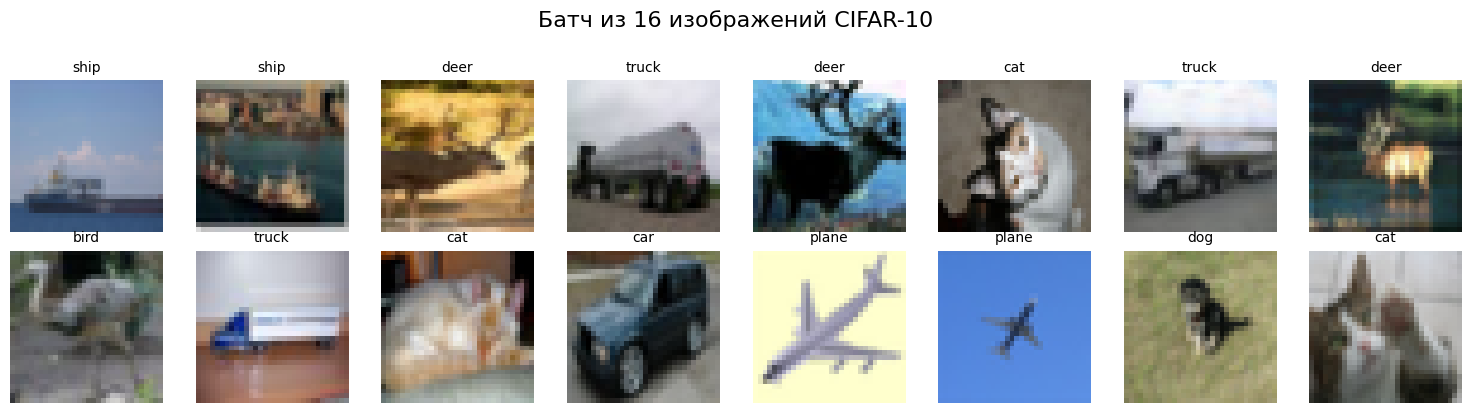

In [3]:
# Отрисуем батч картинок

def visualize_batch(images, labels, classes, ncols=8):

    batch_size = images.shape[0]
    nrows = (batch_size + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2 * nrows))


    if nrows == 1:
        axes = axes.reshape(1, -1)

    for idx in range(batch_size):
        row = idx // ncols
        col = idx % ncols


        img = images[idx] / 2 + 0.5
        npimg = img.numpy().transpose(1, 2, 0)


        axes[row, col].imshow(npimg)
        axes[row, col].set_title(f'{classes[labels[idx]]}', fontsize=10)
        axes[row, col].axis('off')


    for idx in range(batch_size, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].axis('off')

    plt.suptitle(f'Батч из {batch_size} изображений CIFAR-10', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)
visualize_batch(images, labels, classes, ncols=8)

In [47]:
# Функции для расчета метрик модели

def count_parameteres(model):
    """ Считаем парметры модели """
    count_parm = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Количество параметров модели: {count_parm}')

def accuracy(pred, label):
    answer = F.softmax(pred.detach()).numpy().argmax(1) == label.numpy()
    return answer.mean()

def evaluate(model, dataloader, device, loss_fn, use_amp):
    model.eval()
    loss_val = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for img, label in dataloader:
            img, label = img.to(device), label.to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(img)
                loss = loss_fn(pred, label)

            loss_val += loss.item()
            all_preds.append(pred.argmax(dim=1).cpu().numpy())
            all_labels.append(label.cpu().numpy())

    avg_loss = loss_val / len(dataloader)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy_val = (all_preds == all_labels).mean()
    return avg_loss, accuracy_val, precision, recall, f1


In [5]:
# Архитектура модели

class ResBlock(nn.Module):
    def __init__(self, num_ch):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(num_ch, num_ch, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm2d(num_ch)
        self.act = nn.ReLU()
        self.conv2 = nn.Conv2d(num_ch, num_ch,kernel_size=3, padding=1)
        self.norm2 = nn.BatchNorm2d(num_ch)

    def forward(self, x):
        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)
        out = self.conv2(out)
        out = self.norm2(out)

        return self.act(x + out)


class ResTruck(nn.Module):
    def __init__(self, num_ch, num_blocks):
        super(ResTruck, self).__init__()

        truck = []
        for i in range(num_blocks):
            truck.append(ResBlock(num_ch))
        self.truck = nn.Sequential(*truck)

    def forward(self, x):
        return self.truck(x)


class ResNet(nn.Module):
    def __init__(self, in_ch, num_ch, out_ch):
        super(ResNet, self).__init__()

        self.conv0 = nn.Conv2d(in_ch, num_ch, kernel_size=7, stride=2, padding=3)
        self.norm = nn.BatchNorm2d(num_ch)
        self.act = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2,2, padding=1)

        self.layer1 = ResTruck(num_ch, 3)
        self.conv1 = nn.Conv2d(num_ch, 2*num_ch, 3, padding=1, stride=2)

        self.layer2 = ResTruck(2*num_ch, 4)
        self.conv2 = nn.Conv2d(2*num_ch, 4*num_ch, 3, padding=1, stride=2)

        self.layer3 = ResTruck(4*num_ch, 6)
        self.conv3 = nn.Conv2d(4*num_ch, 8*num_ch, 3, padding=1, stride=2)

        self.layer4 = ResTruck(8*num_ch, 3)

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1,1))
        self.linear = nn.Linear(in_features=8*num_ch, out_features=out_ch)

    def forward(self, x):
        x = self.conv0(x)
        # x = self.norm(x)
        x = self.act(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.conv1(x)
        x = self.layer2(x)
        x = self.conv2(x)
        x = self.layer3(x)
        x = self.conv3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = self.linear(torch.flatten(x, 1))

        return x

In [36]:
# Инициализация модели

model = ResNet(3, 64, 10)
count_parameters(model)

АНАЛИЗ ПАРАМЕТРОВ МОДЕЛИ
Общее количество параметров: 24,221,066
В миллионах: 24.22M
В гигабайтах (float32): 0.10 GB


24221066

In [42]:
# Обучение


# device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используется устройство: {device}")

# Инициализация модели и функции потерь
model = ResNet(3, 64, 10).to(device)
loss_fn = nn.CrossEntropyLoss().to(device)

# Инициализация TensorBoard
log_dir = f"runs/resnet34_{time.strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir=log_dir)

# Логируем конфигурацию обучения
config_text = f"""
Конфигурация обучения:
- Модель: ResNet
- Learning rate: 0.001
- Epochs: 10
- Batch size: {trainloader.batch_size}
- Optimizer: AdamW
- Scheduler: ExponentialLR
- Device: {device}
"""
writer.add_text("Конфигурация", config_text)

# Считаем параметры модели
count_parameteres(model)

# Инициализация оптимизатора и планировщика
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, betas=(0.8, 0.999))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.6)

# Настройка mixed precision и CUDA
use_amp = True
scaler = torch.cuda.amp.GradScaler()
torch.backends.cudnn.benchmark = True

# Переменные для отслеживания метрик
epochs = 10
train_loss = []
test_loss = []
acc_train_list = []
acc_test_list = []
precision_list = []
recall_list = []
f1_list = []

print("Начинаем обучение...")
print(f"Логи TensorBoard будут сохранены в: {log_dir}")
print("Для просмотра запустите: tensorboard --logdir=runs")

for epoch in range(epochs):
    model.train()
    loss_val = 0
    acc_val = 0
    start_time = time.time()

    for sample in tqdm(trainloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        img, label = sample
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(img)
            loss = loss_fn(pred, label)

        scaler.scale(loss).backward()
        loss_item = loss.item()
        loss_val += loss_item

        scaler.step(optimizer)
        scaler.update()

        # Используем вашу функцию accuracy
        acc_current = accuracy(pred.cpu().float(), label.cpu().float())
        acc_val += acc_current

    scheduler.step()

    # Расчет метрик для тренировочных данных
    train_loss_epoch = loss_val / len(trainloader)
    train_acc_epoch = acc_val / len(trainloader)
    train_loss.append(train_loss_epoch)
    acc_train_list.append(train_acc_epoch)

    # Получение метрик для тестовых данных с помощью вашей функции evaluate
    test_loss_epoch, test_acc_epoch, precision_epoch, recall_epoch, f1_epoch = evaluate(
        model, testloader, device, loss_fn, use_amp
    )
    test_loss.append(test_loss_epoch)
    acc_test_list.append(test_acc_epoch)
    precision_list.append(precision_epoch)
    recall_list.append(recall_epoch)
    f1_list.append(f1_epoch)

    # Получаем текущий learning rate
    current_lr = scheduler.get_last_lr()[0]

    # Логируем метрики в TensorBoard
    writer.add_scalar('Loss/train', train_loss_epoch, epoch)
    writer.add_scalar('Loss/test', test_loss_epoch, epoch)
    writer.add_scalar('Accuracy/train', train_acc_epoch, epoch)
    writer.add_scalar('Accuracy/test', test_acc_epoch, epoch)
    writer.add_scalar('Metrics/precision', precision_epoch, epoch)
    writer.add_scalar('Metrics/recall', recall_epoch, epoch)
    writer.add_scalar('Metrics/f1_score', f1_epoch, epoch)
    writer.add_scalar('Learning_rate', current_lr, epoch)

    # Логируем время эпохи
    epoch_time = time.time() - start_time
    writer.add_scalar('Time/epoch_time', epoch_time, epoch)

    # Логируем гистограммы весов (каждые 5 эпох чтобы не перегружать)
    if epoch % 5 == 0:
        for name, param in model.named_parameters():
            if param.requires_grad and 'weight' in name:
                writer.add_histogram(f'Weights/{name}', param, epoch)
                if param.grad is not None:
                    writer.add_histogram(f'Gradients/{name}', param.grad, epoch)

    # Вывод в консоль
    print(f'\nEpoch: {epoch + 1}/{epochs}')
    print(f'Train Loss: {train_loss_epoch:.4f} | Train Accuracy: {train_acc_epoch:.4f}')
    print(f'Test Loss: {test_loss_epoch:.4f} | Test Accuracy: {test_acc_epoch:.4f}')
    print(f'Precision: {precision_epoch:.4f} | Recall: {recall_epoch:.4f} | F1-Score: {f1_epoch:.4f}')
    print(f'Learning Rate: {current_lr:.6f} | Epoch Time: {epoch_time:.2f}s')
    print('-' * 70)

# Закрываем writer
writer.close()

# Сохраняем финальные метрики
final_metrics = {
    'final_train_accuracy': acc_train_list[-1],
    'final_test_accuracy': acc_test_list[-1],
    'final_test_loss': test_loss[-1],
    'best_test_accuracy': max(acc_test_list),
    'best_epoch': acc_test_list.index(max(acc_test_list)) + 1
}

# Логируем финальные метрики в TensorBoard
final_metrics_text = f"""
Финальные метрики:
- Лучшая точность: {final_metrics['best_test_accuracy']:.4f} на эпохе {final_metrics['best_epoch']}
- Финальная точность: {final_metrics['final_test_accuracy']:.4f}
- Финальные потери: {final_metrics['final_test_loss']:.4f}
"""
writer.add_text("Финальные метрики", final_metrics_text)

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=" * 70)
print(f"Лучшая точность: {final_metrics['best_test_accuracy']:.4f} на эпохе {final_metrics['best_epoch']}")
print(f"Финальная точность: {final_metrics['final_test_accuracy']:.4f}")
print(f"Финальные потери: {final_metrics['final_test_loss']:.4f}")
print("=" * 70)
print(f"\nДля просмотра графиков запустите:")
print(f"tensorboard --logdir=runs")

Используется устройство: cuda
Количество параметров модели: 24221066
Начинаем обучение...
Логи TensorBoard будут сохранены в: runs/resnet34_20251012_165250
Для просмотра запустите: tensorboard --logdir=runs


Epoch 1/10: 100%|██████████| 3125/3125 [01:52<00:00, 27.67it/s]



Epoch: 1/10
Train Loss: 1.6467 | Train Accuracy: 0.3897
Test Loss: 1.3305 | Test Accuracy: 0.5216
Precision: 0.5350 | Recall: 0.5216 | F1-Score: 0.5167
Learning Rate: 0.000600 | Epoch Time: 121.13s
----------------------------------------------------------------------


Epoch 2/10: 100%|██████████| 3125/3125 [01:52<00:00, 27.73it/s]



Epoch: 2/10
Train Loss: 1.1394 | Train Accuracy: 0.5874
Test Loss: 1.0447 | Test Accuracy: 0.6286
Precision: 0.6322 | Recall: 0.6286 | F1-Score: 0.6212
Learning Rate: 0.000360 | Epoch Time: 120.91s
----------------------------------------------------------------------


...


Epoch: 8/10
Train Loss: 0.3698 | Train Accuracy: 0.8716
Test Loss: 0.7539 | Test Accuracy: 0.7530
Precision: 0.7538 | Recall: 0.7530 | F1-Score: 0.7529
Learning Rate: 0.000017 | Epoch Time: 122.62s
----------------------------------------------------------------------


Epoch 9/10: 100%|██████████| 3125/3125 [01:53<00:00, 27.60it/s]



Epoch: 9/10
Train Loss: 0.3331 | Train Accuracy: 0.8869
Test Loss: 0.7638 | Test Accuracy: 0.7551
Precision: 0.7547 | Recall: 0.7551 | F1-Score: 0.7546
Learning Rate: 0.000010 | Epoch Time: 121.40s
----------------------------------------------------------------------


Epoch 10/10: 100%|██████████| 3125/3125 [01:54<00:00, 27.30it/s]



Epoch: 10/10
Train Loss: 0.3096 | Train Accuracy: 0.8954
Test Loss: 0.7718 | Test Accuracy: 0.7551
Precision: 0.7542 | Recall: 0.7551 | F1-Score: 0.7543
Learning Rate: 0.000006 | Epoch Time: 122.67s
----------------------------------------------------------------------

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Лучшая точность: 0.7551 на эпохе 9
Финальная точность: 0.7551
Финальные потери: 0.7718

Для просмотра графиков запустите:
tensorboard --logdir=runs


In [43]:
# Точность модели в разрезе классов

model = model.to(device)

correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            total_per_class[label.item()] += 1
            if label.item() == pred.item():
                correct_per_class[label.item()] += 1

per_class_accuracy = {}
for cls_idx in range(len(classes)):
    accuracy = correct_per_class[cls_idx] / total_per_class[cls_idx] if total_per_class[cls_idx] > 0 else 0
    per_class_accuracy[classes[cls_idx]] = accuracy

print("=" * 50)
print("ТОЧНОСТЬ ПО КЛАССАМ")
print("=" * 50)
for cls_name, acc in per_class_accuracy.items():
    print(f"{cls_name:12}: {acc * 100:.2f}%")

# Общая точность
total_correct = sum(correct_per_class.values())
total_samples = sum(total_per_class.values())
overall_accuracy = total_correct / total_samples
print("=" * 50)
print(f"Общая точность: {overall_accuracy * 100:.2f}%")
print(f"Правильно классифицировано: {total_correct}/{total_samples}")

Используется устройство: cuda
ТОЧНОСТЬ ПО КЛАССАМ
plane       : 78.10%
car         : 85.70%
bird        : 66.90%
cat         : 55.70%
deer        : 69.90%
dog         : 64.70%
frog        : 85.30%
horse       : 78.40%
ship        : 88.40%
truck       : 81.80%
Общая точность: 75.49%
Правильно классифицировано: 7549/10000


=== ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ МОДЕЛИ ===


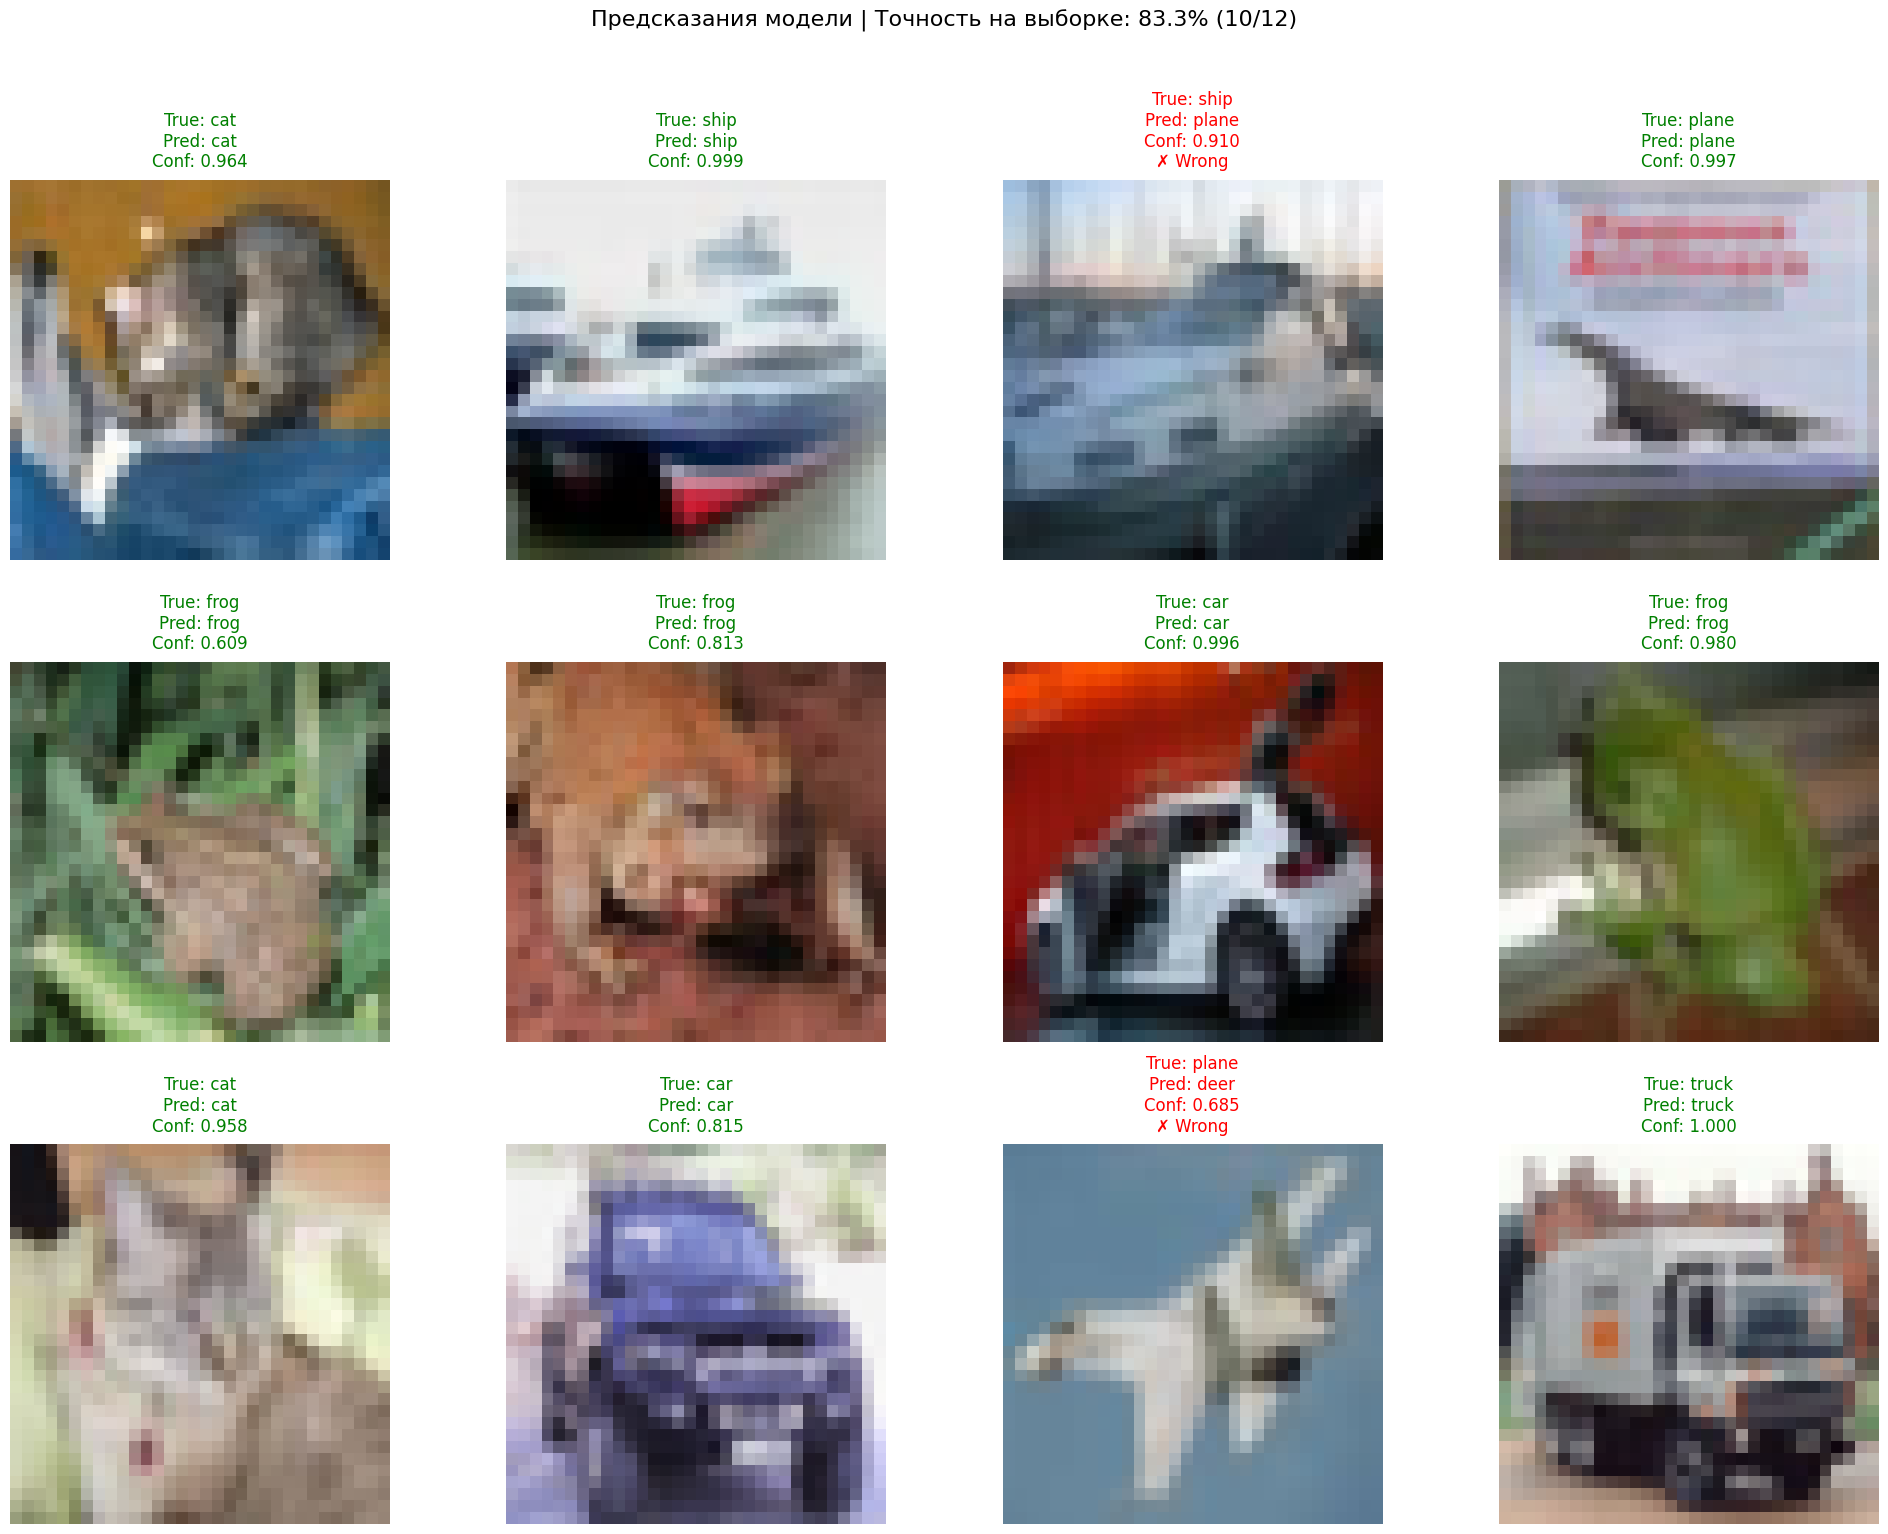


=== АНАЛИЗ ОШИБОК ===


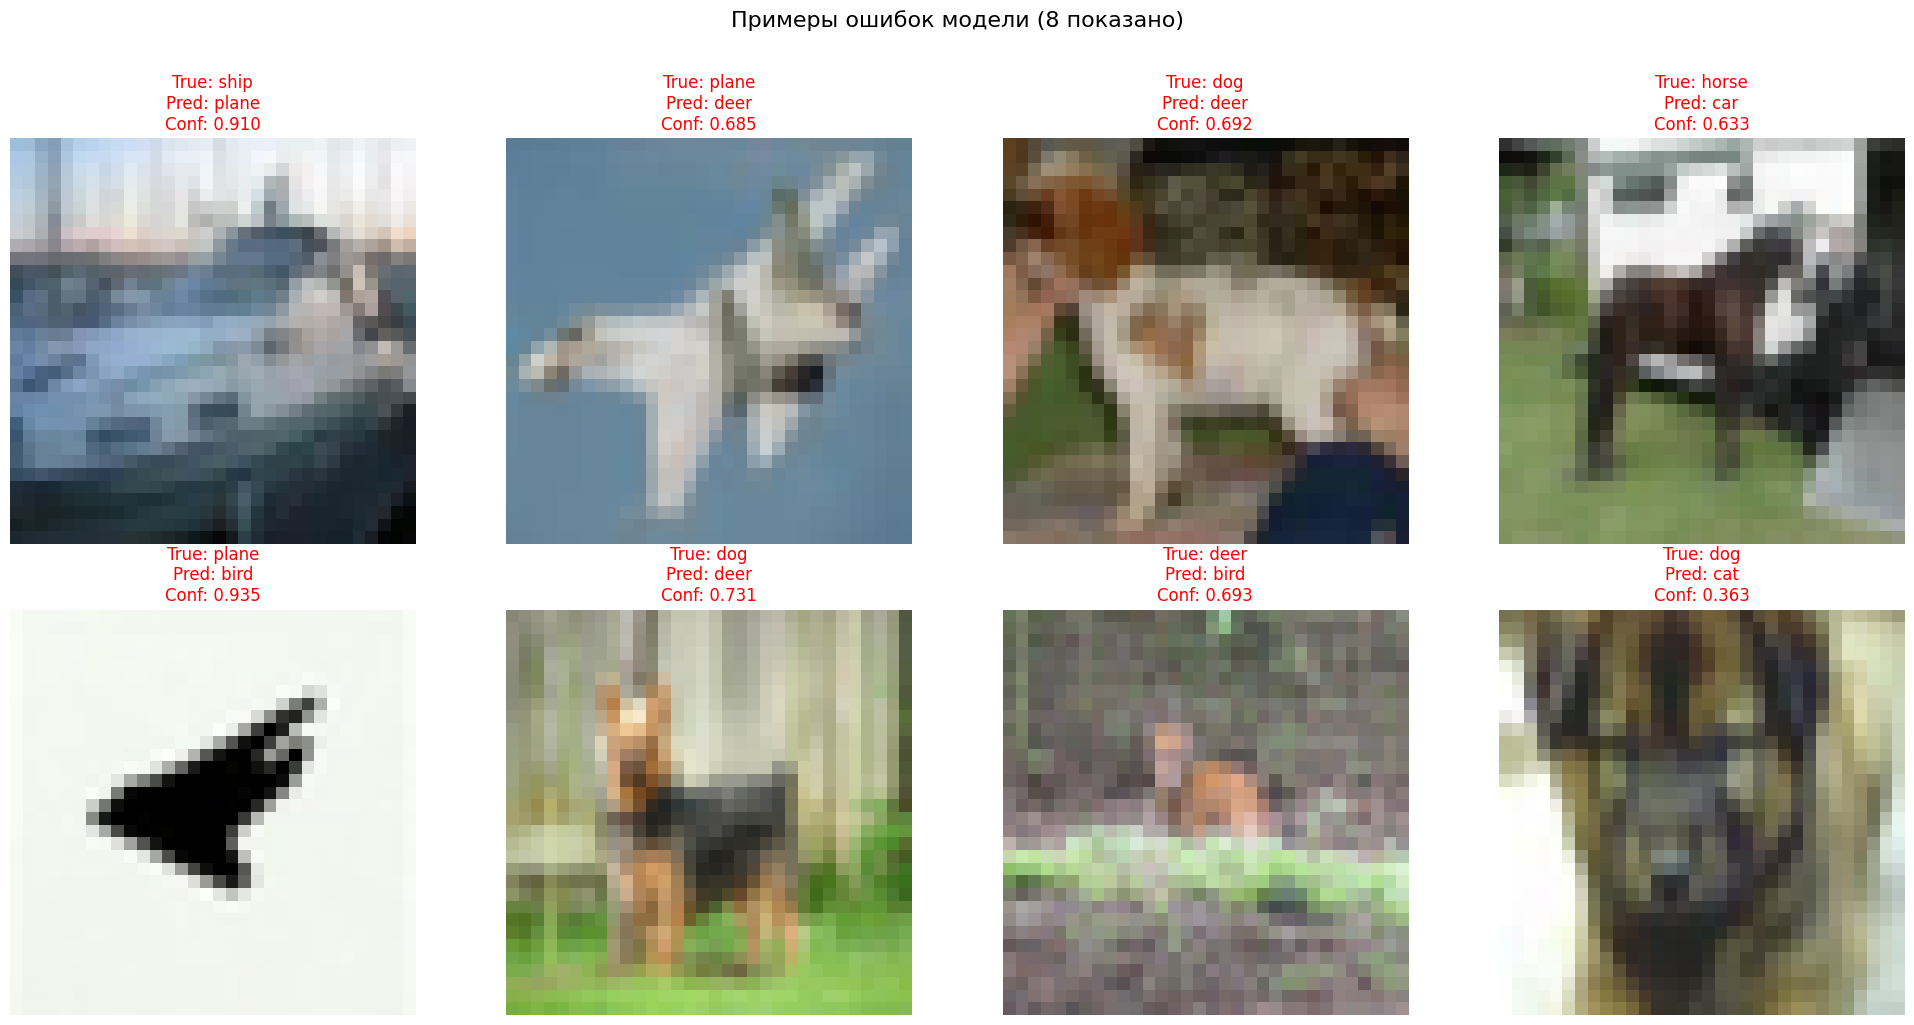

In [46]:
# Визаулизация результатов


@torch.no_grad()
def visualize_predictions(model, dataloader, class_names, num_images=12):

    model.eval()
    device = next(model.parameters()).device


    images_list = []
    true_labels_list = []
    pred_labels_list = []
    probabilities_list = []

    # Проходим по даталоадеру и собираем предсказания
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        for i in range(images.size(0)):
            if len(images_list) >= num_images:
                break

            images_list.append(images[i].cpu())
            true_labels_list.append(labels[i].item())
            pred_labels_list.append(preds[i].item())
            probabilities_list.append(probabilities[i].cpu().numpy())

        if len(images_list) >= num_images:
            break

    # Создаем график
    n_cols = 4
    n_rows = (num_images + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))


    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_images):
        if idx >= len(images_list):
            break

        row = idx // n_cols
        col = idx % n_cols

        # Денормализуем изображение
        image = images_list[idx].numpy().transpose((1, 2, 0))
        image = np.clip(
            image * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5]),
            0, 1
        )

        true_label = true_labels_list[idx]
        pred_label = pred_labels_list[idx]
        confidence = probabilities_list[idx][pred_label]

        true_class = class_names[true_label]
        pred_class = class_names[pred_label]


        is_correct = true_label == pred_label
        title_color = 'green' if is_correct else 'red'


        axes[row, col].imshow(image)


        title = f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.3f}"
        if not is_correct:
            title += f"\n✗ Wrong"

        axes[row, col].set_title(title, color=title_color, fontsize=12, pad=10)
        axes[row, col].axis('off')

        # Добавляем рамку в зависимости от правильности предсказания
        border_color = 'green' if is_correct else 'red'
        border_width = 3 if not is_correct else 2
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)


    for idx in range(len(images_list), n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    # Добавляем общую статистику
    correct_predictions = sum(1 for t, p in zip(true_labels_list, pred_labels_list) if t == p)
    accuracy = correct_predictions / len(true_labels_list)

    plt.suptitle(
        f'Предсказания модели | Точность на выборке: {accuracy:.1%} ({correct_predictions}/{len(true_labels_list)})',
        fontsize=16,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

    return {
        'images': images_list,
        'true_labels': true_labels_list,
        'pred_labels': pred_labels_list,
        'probabilities': probabilities_list,
        'accuracy': accuracy
    }

# Дополнительная функция для детального анализа ошибок
@torch.no_grad()
def analyze_errors(model, dataloader, class_names, num_errors=8):
    """
    Анализирует и отображает примеры, где модель ошиблась.
    """
    model.eval()
    device = next(model.parameters()).device

    errors = []

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        for i in range(images.size(0)):
            if labels[i] != preds[i]:  # Если модель ошиблась
                errors.append({
                    'image': images[i].cpu(),
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'probability': probabilities[i][preds[i]].item(),
                    'all_probabilities': probabilities[i].cpu().numpy()
                })

            if len(errors) >= num_errors:
                break

        if len(errors) >= num_errors:
            break

    # Отображаем ошибки
    if errors:
        n_cols = 4
        n_rows = (len(errors) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

        if n_rows == 1:
            axes = axes.reshape(1, -1)

        for idx, error in enumerate(errors):
            if idx >= len(axes.flat):
                break

            row = idx // n_cols
            col = idx % n_cols

            # Денормализуем изображение
            image = error['image'].numpy().transpose((1, 2, 0))
            image = np.clip(
                image * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5]),
                0, 1
            )

            true_class = class_names[error['true_label']]
            pred_class = class_names[error['pred_label']]
            confidence = error['probability']

            axes[row, col].imshow(image)
            axes[row, col].set_title(
                f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.3f}",
                color='red',
                fontsize=12
            )
            axes[row, col].axis('off')

            for spine in axes[row, col].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)

        # Скрываем пустые subplots
        for idx in range(len(errors), n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            axes[row, col].axis('off')

        plt.suptitle(f'Примеры ошибок модели ({len(errors)} показано)', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

    return errors

# Использование улучшенной визуализации
print("=== ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ МОДЕЛИ ===")
results = visualize_predictions(model, testloader, classes, num_images=12)

print("\n=== АНАЛИЗ ОШИБОК ===")
errors = analyze_errors(model, testloader, classes, num_errors=8)